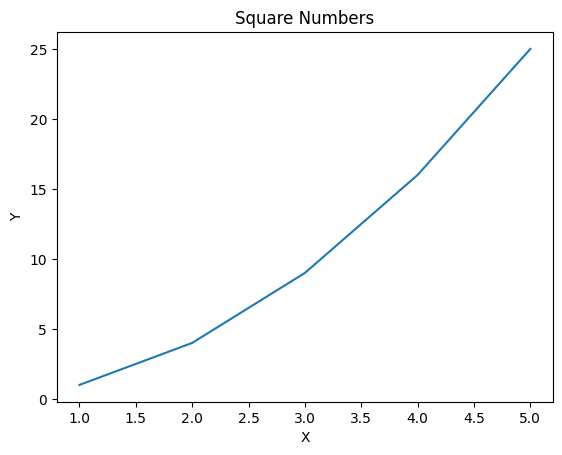

In [1]:
# Listing 1.1 Imperative library

import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [1, 4, 9, 16, 25]

plt.plot(x, y)
plt.title('Square Numbers')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

In [3]:
# Listing 1.2 Imperative library

import altair as alt
import pandas as pd

df = pd.DataFrame({'x': [1, 2, 3, 4, 5], 'y': [1, 4, 9, 16, 25]})

chart = alt.Chart(df).mark_line().encode(
    x='x',
    y='y'
).properties(
    title='Square Numbers'
)

chart


alt.Chart(...)

In [4]:
# Listing 2.1 Chart in Altair

import altair as alt
import pandas as pd

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}

# Create the DataFrame from the data
df = pd.DataFrame(data)

# Print the dataframe
print(df)

# Create the chart
chart = alt.Chart(df)


      Name  Age      City
0    Alice   25  New York
1      Bob   30     Paris
2  Charlie   35    London


In [8]:
# Listing 2.2 Mark in Altair

chart = alt.Chart(df).mark_bar()

In [14]:
# Listing 2.3 Encodings in Altair

import pandas as pd
import altair as alt

# Create data for the DataFrame
data = {'Name': ['Alice', 'Bob', 'Charlie'],
        'Age': [25, 30, 35],
        'City': ['New York', 'Paris', 'London']
}


# Create the DataFrame from the data
df = pd.DataFrame(data)

# Create the chart
chart = alt.Chart(df).mark_bar(
).encode(
    x = 'Age:Q',
    y = 'Name:N'
)

chart.save('chart.html')

# to plot the chart inline.
chart.display()

alt.Chart(...)

In [13]:
# save to laptop
# - you will be prompted to provide the destination

from google.colab import files
files.download('/content/chart.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
# Listing 2.4 Loading the dataset as a Pandas DataFrame

# import file from laptop
# from google.colab import files
#uploaded = files.upload()
#
# The aboved failed. uploaded file manually using "upload" command from "content"
#   folder context menu

import pandas as pd

df = pd.read_csv('/content/tourist_arrivals_countries.csv', parse_dates=['Date'])


In [ ]:
# Listing 2.5 Building a summary report

In [10]:
# install missing module ydata_profiling
!pip install ydata_profiling

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.3/357.3 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 11.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 23.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 28.4 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=959ffda072aa0a7f737eb7a01e3a1ad351af83dde464d78f4f56d0ab70df5252
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.3.0
    Uninstalling pydantic-2.3.0:
      Successfully uninstalled pydantic-2.3.0


In [11]:
from ydata_profiling import ProfileReport

eda = ProfileReport(df)
eda.to_file(output_file='eda.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# Listing 2.6 Building the raw chart in Altair

import altair as alt

df2 = pd.melt(df,
              id_vars='Date',
              value_name='Tourist Arrivals',
              var_name='Country')

chart = alt.Chart(df2).mark_line().encode(
    x = 'Date:T',
    y = 'Tourist Arrivals:Q',
    color=alt.Color('Country:N')
)

chart.save('chart.html')

In [13]:
# Listing 2.7 Removing missing values from the dataset

mask_fr = df['FR'].isnull() == False
mask_uk = df['UK'].isnull() == False
mask_es = df['ES'].isnull() == False
df = df[(mask_fr) & (mask_uk) & (mask_es)]